# Credit Risk Prediction using Machine Learning
## Exploratory Data Analysis (EDA)

### Project Overview

Credit risk assessment is a fundamental problem in the financial industry, where lenders evaluate the likelihood that a borrower will fail to repay a loan. Accurate prediction of loan defaults enables financial institutions to reduce losses, improve portfolio quality, optimize lending decisions, and comply with regulatory requirements.

This notebook presents the Exploratory Data Analysis (EDA) phase of a production-grade Credit Risk Prediction project built using the Lending Club Accepted Loans dataset. The primary objective of this analysis is to develop a comprehensive understanding of the dataset before feature engineering and machine learning model development.

Rather than performing one-off exploratory analysis, this project follows a modular and reusable architecture. A dedicated EDA pipeline has been developed consisting of data loading, profiling, validation, and specialized analyzers that generate reusable analytical summaries. This approach improves maintainability, reproducibility, and scalability while keeping the notebook focused on interpretation rather than implementation.

The analysis performed in this notebook includes:

- Dataset overview and structural validation
- Automated data profiling
- Target variable analysis
- Missing value analysis
- Numerical feature analysis
- Categorical feature analysis
- Correlation analysis
- Outlier detection
- Business observations and preprocessing recommendations

The insights obtained during this phase will directly guide feature engineering, preprocessing strategies, feature selection, and subsequent machine learning model development.

In [41]:
# =========================
# Standard Library
# =========================
import warnings

# =========================
# Third-Party Libraries
# =========================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# =========================
# Project Imports
# =========================
from src.config.paths import ProjectPaths
from src.config.settings import DataConfig
from src.data.dictionary import DataDictionary
from src.data.leakage import LeakageAnalyzer
from src.data.loader import DatasetLoader
from src.data.profiler import DataProfiler
from src.data.target import TargetBuilder
from src.eda.engine import EDAEngine

# =========================
# Notebook Configuration
# =========================
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# 1. Dataset Loading

In [2]:
config = DataConfig()

loader = DatasetLoader(config)
df = loader.load(ProjectPaths.ACCEPTED_LOANS)

2026-08-09 09:40:05 | INFO     | src.data.loader | Loading dataset: accepted_2007_to_2018Q4.csv


In [3]:
profiler = DataProfiler()
profile = profiler.profile(df)

2026-08-09 09:40:50 | INFO     | src.data.profiler | Generating dataset profile.
2026-08-09 09:41:41 | INFO     | src.data.profiler | Dataset profiling completed.


# 1. Dataset Overview

Before performing exploratory analysis, it is essential to verify the integrity and structure of the dataset. This section loads the Lending Club accepted loans dataset using the project's reusable data loading utilities and generates a high-level overview including dataset dimensions, feature composition, descriptive statistics, and the associated data dictionary.

This validation step ensures that the dataset has been loaded correctly and provides an initial understanding of the available information before deeper analysis.

In [4]:
from dataclasses import asdict

# Generate data dictionary
dictionary = DataDictionary().generate(df)

# Display dictionary
display(pd.DataFrame([asdict(entry) for entry in dictionary]))

2026-08-09 09:41:41 | INFO     | src.data.dictionary | Generating data dictionary.
2026-08-09 09:41:52 | INFO     | src.data.dictionary | Generated 151 dictionary entries.


,column,dtype,missing_count,missing_percentage,unique_count
0,id,object,0,0.00,2260701
1,member_id,float64,2260701,100.00,0
2,loan_amnt,float64,33,0.00,1572
3,funded_amnt,float64,33,0.00,1572
4,funded_amnt_inv,float64,33,0.00,10057
...,...,...,...,...,...
146,settlement_status,object,2226455,98.49,3
147,settlement_date,object,2226455,98.49,90
148,settlement_amount,float64,2226455,98.49,21941
149,settlement_percentage,float64,2226455,98.49,2070


# 3. Data Profiling

In [5]:
profile.descriptive_statistics

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,2260701,2260701,68407277,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
member_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,2260668.0,NaN,NaN,NaN,15046.931228,9190.245488,500.0,8000.0,12900.0,20000.0,40000.0
funded_amnt,2260668.0,NaN,NaN,NaN,15041.664057,9188.413022,500.0,8000.0,12875.0,20000.0,40000.0
funded_amnt_inv,2260668.0,NaN,NaN,NaN,15023.437745,9192.331679,0.0,8000.0,12800.0,20000.0,40000.0
...,...,...,...,...,...,...,...,...,...,...,...
settlement_status,34246,3,ACTIVE,14704,NaN,NaN,NaN,NaN,NaN,NaN,NaN
settlement_date,34246,90,Jan-2019,1710,NaN,NaN,NaN,NaN,NaN,NaN,NaN
settlement_amount,34246.0,NaN,NaN,NaN,5010.664267,3693.12259,44.21,2208.0,4146.11,6850.1725,33601.0
settlement_percentage,34246.0,NaN,NaN,NaN,47.780365,7.311822,0.2,45.0,45.0,50.0,521.35


# 4. Exploratory Data Analysis

In [6]:
engine = EDAEngine(
    df=df,
    target_column="loan_status",
)

report = engine.run()

2026-08-09 09:41:52 | INFO     | src.eda.engine | Starting EDA pipeline.
2026-08-09 09:41:52 | INFO     | src.data.profiler | Generating dataset profile.
2026-08-09 09:42:32 | INFO     | src.data.profiler | Dataset profiling completed.
2026-08-09 09:42:32 | INFO     | src.eda.target | Analyzing target column 'loan_status'.
2026-08-09 09:42:32 | INFO     | src.eda.target | Target analysis completed. Found 9 classes.
2026-08-09 09:42:32 | INFO     | src.eda.missing | Analyzing missing values.
2026-08-09 09:42:32 | INFO     | src.eda.missing | Missing value analysis completed. 150 columns contain missing values.
2026-08-09 09:42:32 | INFO     | src.eda.numeric | Analyzing numerical features.
2026-08-09 09:42:50 | INFO     | src.eda.numeric | Numeric feature analysis completed.
2026-08-09 09:42:50 | INFO     | src.eda.categorical | Analyzing categorical features.
2026-08-09 09:42:58 | INFO     | src.eda.categorical | Categorical feature analysis completed.
2026-08-09 09:42:58 | INFO     | 

## 4.1 Target Variable Analysis

In [7]:
report.target

TargetSummary(target_column='loan_status', total_samples=2260701, missing_values=33, n_classes=9, unique_labels=['Fully Paid', 'Current', 'Charged Off', 'In Grace Period', 'Late (31-120 days)', 'Late (16-30 days)', 'Default', 'Does not meet the credit policy. Status:Fully Paid', 'Does not meet the credit policy. Status:Charged Off'], class_counts=loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
NaN                                                         33
Name: cou

## 4.2 Missing Value Analysis

In [8]:
report.missing
pd.DataFrame(
    {
        "Missing Count": report.missing.missing_counts,
        "Missing %": report.missing.missing_percentages,
    }
).head(20)

,Missing Count,Missing %
member_id,2260701,100.00
orig_projected_additional_accrued_interest,2252050,99.62
hardship_type,2249784,99.52
hardship_reason,2249784,99.52
hardship_status,2249784,99.52
deferral_term,2249784,99.52
hardship_amount,2249784,99.52
hardship_start_date,2249784,99.52
hardship_end_date,2249784,99.52
payment_plan_start_date,2249784,99.52


## 4.3 Numerical Feature Analysis

In [9]:
pd.Series(report.numeric.skewness).sort_values()

last_fico_range_low        -3.7373
pct_tl_nvr_dlq             -2.2779
last_fico_range_high       -0.7567
mths_since_last_record     -0.3693
bc_util                    -0.2698
                            ...   
num_tl_120dpd_2m           55.8098
delinq_amnt               102.6548
annual_inc                493.8861
tot_coll_amt              852.0101
member_id                      NaN
Length: 113, dtype: float64

In [10]:
pd.Series(report.numeric.kurtosis).sort_values()

hardship_dpd                               -1.2989
percent_bc_gt_75                           -1.2557
bc_util                                    -1.0012
sec_app_mths_since_last_major_derog        -0.7008
mths_since_last_delinq                     -0.6936
                                          ...     
total_rev_hi_lim                         7520.9266
delinq_amnt                             16006.0037
annual_inc                             439001.6589
tot_coll_amt                           803765.2461
member_id                                      NaN
Length: 113, dtype: float64

## 4.4 Categorical Feature Analysis

In [11]:
pd.Series(report.categorical.cardinality).sort_values(ascending=False)

id                           2260701
url                          2260668
emp_title                     512694
desc                          124500
title                          63154
zip_code                         956
earliest_cr_line                 754
sec_app_earliest_cr_line         663
last_credit_pull_d               141
issue_d                          139
last_pymnt_d                     136
next_pymnt_d                     106
settlement_date                   90
debt_settlement_flag_date         83
addr_state                        51
sub_grade                         35
hardship_end_date                 28
hardship_start_date               27
payment_plan_start_date           27
purpose                           14
emp_length                        11
loan_status                        9
hardship_reason                    9
grade                              7
home_ownership                     6
hardship_loan_status               5
hardship_status                    3
v

## 4.5 Correlation Analysis

In [12]:
len(report.correlation.high_correlation_pairs)

4758

In [13]:
list(report.correlation.high_correlation_pairs)[:20]

[('loan_amnt', 'funded_amnt', 0.9998),
 ('loan_amnt', 'funded_amnt_inv', 0.999),
 ('loan_amnt', 'int_rate', 0.0981),
 ('loan_amnt', 'installment', 0.9456),
 ('loan_amnt', 'annual_inc', 0.1972),
 ('loan_amnt', 'dti', 0.0435),
 ('loan_amnt', 'fico_range_low', 0.1106),
 ('loan_amnt', 'fico_range_high', 0.1106),
 ('loan_amnt', 'inq_last_6mths', -0.0278),
 ('loan_amnt', 'mths_since_last_delinq', -0.0108),
 ('loan_amnt', 'mths_since_last_record', 0.0163),
 ('loan_amnt', 'open_acc', 0.1822),
 ('loan_amnt', 'pub_rec', -0.0588),
 ('loan_amnt', 'revol_bal', 0.3167),
 ('loan_amnt', 'revol_util', 0.0991),
 ('loan_amnt', 'total_acc', 0.1996),
 ('loan_amnt', 'out_prncp', 0.4622),
 ('loan_amnt', 'out_prncp_inv', 0.4622),
 ('loan_amnt', 'total_pymnt', 0.6682),
 ('loan_amnt', 'total_pymnt_inv', 0.6683)]

## 4.6 Outlier Analysis

In [14]:
pd.Series(report.outliers.outlier_percentages).sort_values(ascending=False)

num_accts_ever_120_pd                  22.25
delinq_2yrs                            18.65
pub_rec                                15.83
tot_coll_amt                           14.79
last_pymnt_amnt                        13.86
                                       ...  
sec_app_mths_since_last_major_derog     0.00
deferral_term                           0.00
hardship_dpd                            0.00
hardship_length                         0.00
settlement_term                         0.00
Length: 113, dtype: float64

# Business EDA Dataset

Before performing business-oriented exploratory data analysis, features identified as
**DROP** or **LEAKAGE** during the data understanding phase are removed.

The resulting dataset contains only:

- KEEP features
- REVIEW features
- TARGET

This dataset serves as the foundation for all subsequent analyses.

In [15]:
leakage = LeakageAnalyzer()

report = leakage.analyze(df)

eda_columns = report.keep + report.review + report.target

2026-08-09 09:43:47 | INFO     | src.data.leakage | Loading leakage rules from D:\Prep Stuff\Projects\credit-risk-platform\configs\leakage_rules.yaml
2026-08-09 09:43:47 | INFO     | src.data.leakage | Leakage analysis completed. KEEP=85 REVIEW=8 DROP=20 LEAKAGE=37 TARGET=1 UNKNOWN=0


In [16]:
eda_df = df[eda_columns].copy()

In [17]:
eda_df.to_parquet(
    ProjectPaths.EDA_DATASET,
    index=False,
)

print(f"EDA dataset saved to {ProjectPaths.EDA_DATASET}")

EDA dataset saved to D:\Prep Stuff\Projects\credit-risk-platform\data\interim\eda_dataset.parquet


In [18]:
eda_df = pd.read_parquet(
    ProjectPaths.EDA_DATASET,
)

print(f"EDA dataset shape: {eda_df.shape}")

EDA dataset shape: (2260701, 94)


## EDA Dataset Validation

The EDA dataset contains only features classified as **KEEP**, **REVIEW**, or
**TARGET** during data understanding. This validation confirms that the
column-level decisions were applied correctly before business analysis begins.

In [19]:
print(f"Rows: {eda_df.shape[0]:,}")
print(f"Columns: {eda_df.shape[1]:,}")

print("\nTarget column:")
print("loan_status" in eda_df.columns)

print("\nMissing values:")
display(eda_df.isna().sum().sort_values(ascending=False).head(20))

Rows: 2,260,701
Columns: 94

Target column:
True

Missing values:


verification_status_joint         2144971
dti_joint                         2139995
annual_inc_joint                  2139991
mths_since_last_record            1901545
mths_since_recent_bc_dlq          1741000
mths_since_last_major_derog       1679926
mths_since_recent_revol_delinq    1520342
mths_since_last_delinq            1158535
il_util                           1068883
mths_since_rcnt_il                 909957
all_util                           866381
inq_last_12m                       866163
total_cu_tl                        866163
open_acc_6m                        866163
open_il_24m                        866162
open_il_12m                        866162
open_rv_12m                        866162
open_act_il                        866162
total_bal_il                       866162
inq_fi                             866162
dtype: int64

## Loan Amount vs Default

Loan amount represents the amount requested by the borrower. This analysis
examines whether the size of the requested loan is associated with default risk.

We will evaluate:

- Distribution of loan amounts.
- Default rate across loan-amount ranges.
- Whether larger borrowing amounts are associated with higher risk.
- Whether the relationship appears linear or non-linear.

In [20]:
loan_amount_bins = [
    0,
    5000,
    10000,
    15000,
    20000,
    25000,
    30000,
    40000,
    50000,
    np.inf,
]

loan_amount_labels = [
    "<5K",
    "5K–10K",
    "10K–15K",
    "15K–20K",
    "20K–25K",
    "25K–30K",
    "30K–40K",
    "40K–50K",
    "50K+",
]

loan_amount_analysis = eda_df[["loan_amnt", "loan_status"]].copy()

loan_amount_analysis["loan_amount_band"] = pd.cut(
    loan_amount_analysis["loan_amnt"],
    bins=loan_amount_bins,
    labels=loan_amount_labels,
    right=False,
)

In [21]:
loan_amount_summary = loan_amount_analysis.groupby(
    "loan_amount_band", observed=True
).agg(
    loans=("loan_status", "size"),
    default_rate=("loan_status", lambda x: (x == "Charged Off").mean() * 100),
    median_loan_amount=("loan_amnt", "median"),
)

display(loan_amount_summary)

,loans,default_rate,median_loan_amount
loan_amount_band,,,
<5K,214606,9.602714,3100.0
5K–10K,495455,10.861329,7000.0
10K–15K,527006,12.117319,11525.0
15K–20K,355499,13.309742,16000.0
20K–25K,290948,13.097873,21000.0
25K–30K,145311,12.498710,25600.0
30K–40K,198475,12.739136,34500.0
40K–50K,33368,4.222608,40000.0


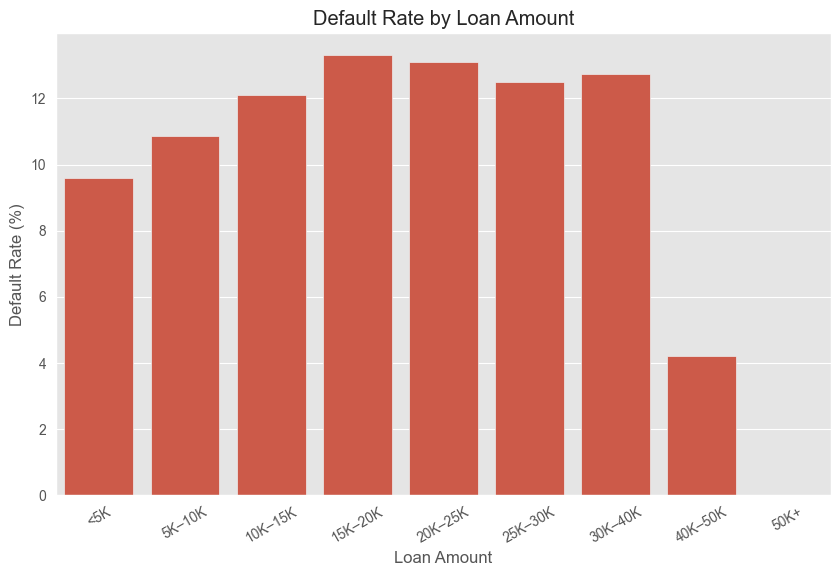

In [22]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=loan_amount_summary.reset_index(),
    x="loan_amount_band",
    y="default_rate",
)

plt.title("Default Rate by Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=30)

plt.show()

In [23]:
display(
    eda_df["loan_amnt"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
)

count    2.260668e+06
mean     1.504693e+04
std      9.190245e+03
min      5.000000e+02
1%       1.525000e+03
5%       3.250000e+03
25%      8.000000e+03
50%      1.290000e+04
75%      2.000000e+04
95%      3.500000e+04
99%      4.000000e+04
max      4.000000e+04
Name: loan_amnt, dtype: float64

In [24]:
print("Maximum loan amount:", eda_df["loan_amnt"].max())

Maximum loan amount: 40000.0


In [25]:
eda_df.loc[eda_df["loan_amnt"] >= 40000, ["loan_amnt", "loan_status"]].groupby(
    "loan_amnt"
)["loan_status"].agg(
    loans="size",
    default_rate=lambda x: (x == "Charged Off").mean() * 100,
).sort_index()

,loans,default_rate
loan_amnt,,
40000.0,33368,4.222608


In [26]:
loan_40k = eda_df[eda_df["loan_amnt"] == 40000]

display(loan_40k["loan_status"].value_counts(normalize=True).mul(100).round(2))

loan_status
Current               77.15
Fully Paid            15.99
Charged Off            4.22
Late (31-120 days)     1.61
In Grace Period        0.63
Late (16-30 days)      0.39
Default                0.01
Name: proportion, dtype: float64

In [27]:
display(
    eda_df.groupby(eda_df["loan_amnt"] == 40000)[
        ["annual_inc", "dti", "int_rate"]
    ].median()
)

,annual_inc,dti,int_rate
loan_amnt,,,
False,65000.0,17.86,12.69
True,120000.0,16.20,10.42


### Observations

- Loan amounts range from **$500 to $40,000**, with a median loan amount of **$12,900**.
- Default rates increase from **9.60% for loans below $5,000** to a peak of **13.31% for loans between $15,000 and $20,000**.
- Default rates remain relatively elevated, around **12.5%–13%**, for loans between $20,000 and $40,000.
- Loans at the dataset's maximum amount of **$40,000** show an unusually low observed default rate of **4.22%**.
- The $40,000 group is structurally different from other loans: its median annual income is **$120,000**, compared with **$65,000** for other loans, while median DTI and interest rate are also lower.
- The $40,000 group also contains **77.15% Current loans**, meaning its low observed default rate may partly reflect loan maturity rather than genuinely lower credit risk.
- Therefore, the relationship between loan amount and default does **not appear to be simply linear** and should be interpreted alongside borrower characteristics and loan maturity.

### Business Implication

Loan amount alone does not appear sufficient to explain default risk. Moderate-to-large loans show higher observed default rates, but the unusually low rate among $40,000 loans is strongly influenced by the characteristics and maturity of that borrower cohort. Loan amount should therefore be evaluated jointly with borrower credit quality, affordability, pricing, and loan age.

## Loan Issue Date and Outcome Maturity

Loan status is strongly influenced by how long a loan has been outstanding.
Recent loans may still be classified as `Current` simply because insufficient
time has elapsed for their eventual outcome to be observed.

This analysis examines the relationship between loan issue date and loan status
to determine whether the dataset contains substantial immature loan cohorts.

This is important for defining a reliable default target for modeling.

In [29]:
eda_df["issue_d"].head()

0    Dec-2015
1    Dec-2015
2    Dec-2015
3    Dec-2015
4    Dec-2015
Name: issue_d, dtype: object

In [30]:
eda_df["issue_d"].dtype

dtype('O')

In [31]:
issue_dates = pd.to_datetime(
    eda_df["issue_d"],
    format="%b-%Y",
    errors="coerce",
)

print(issue_dates.min())
print(issue_dates.max())

2007-06-01 00:00:00
2018-12-01 00:00:00


In [32]:
issue_status = eda_df.copy()

issue_status["issue_date"] = pd.to_datetime(
    issue_status["issue_d"],
    format="%b-%Y",
    errors="coerce",
)

issue_status["issue_year"] = issue_status["issue_date"].dt.year

status_by_year = (
    pd.crosstab(
        issue_status["issue_year"],
        issue_status["loan_status"],
        normalize="index",
    )
    .mul(100)
    .round(2)
)

display(status_by_year)

loan_status,Charged Off,Current,Default,Does not meet the credit policy. Status:Charged Off,Does not meet the credit policy. Status:Fully Paid,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days)
issue_year,,,,,,,,,
2007.0,7.46,0.00,0.0,18.74,39.64,34.16,0.00,0.00,0.00
2008.0,10.32,0.00,0.0,10.41,24.32,54.95,0.00,0.00,0.00
2009.0,11.25,0.00,0.0,2.44,8.26,78.05,0.00,0.00,0.00
2010.0,11.86,0.00,0.0,2.15,5.83,80.15,0.00,0.00,0.00
2011.0,15.18,0.00,0.0,0.00,0.00,84.82,0.00,0.00,0.00
2012.0,16.20,0.00,0.0,0.00,0.00,83.80,0.00,0.00,0.00
2013.0,15.59,0.00,0.0,0.00,0.00,84.40,0.00,0.00,0.00
2014.0,17.47,5.06,0.0,0.00,0.00,77.22,0.08,0.03,0.14
2015.0,18.00,10.28,0.0,0.00,0.00,71.18,0.15,0.07,0.32


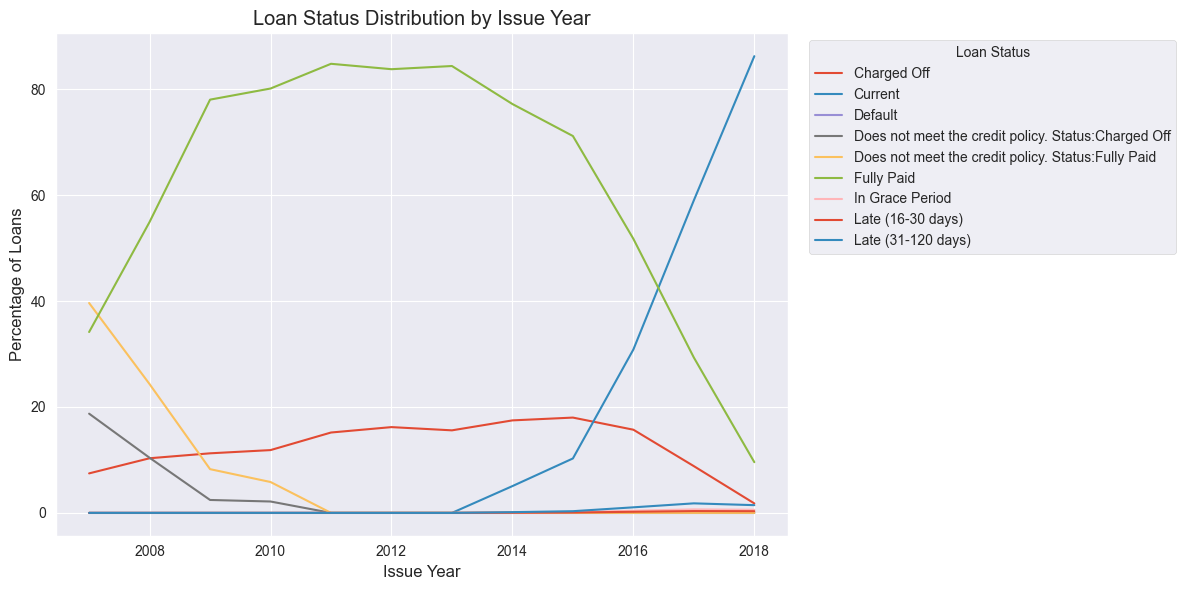

In [33]:
status_by_year.plot(
    kind="line",
    figsize=(12, 6),
)

plt.title("Loan Status Distribution by Issue Year")
plt.xlabel("Issue Year")
plt.ylabel("Percentage of Loans")
plt.legend(title="Loan Status", bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

### Observations

- Loan outcomes vary substantially by issue year.
- Older cohorts (2007–2013) contain almost exclusively finalized outcomes such as
  `Fully Paid` and `Charged Off`, with virtually no `Current` loans.
- Beginning around 2014, `Current` loans appear and increase substantially in
  subsequent cohorts.
- The proportion of `Current` loans rises from **5.06% in 2014** to **86.26% in
  2018**.
- At the same time, the proportion of `Fully Paid` loans falls from **77.22% in
  2014** to **9.58% in 2018**.
- The observed `Charged Off` rate increases through 2015, reaching **18.00%**,
  then declines sharply in newer cohorts.
- The decline in observed `Charged Off` rates in recent years should not be
  interpreted as an improvement in credit quality because recent loans contain
  substantially more loans whose final outcomes have not yet been observed.

### Business Implications

Loan status is strongly affected by loan maturity. Recent cohorts contain a
large proportion of active loans, while older cohorts have had sufficient time
to reach finalized outcomes.

Therefore, comparing raw default rates across issue years would introduce
substantial maturity bias.

### Modeling Implications

The target definition must distinguish loans with sufficiently observed outcomes
from loans that are still active.

`Current`, `In Grace Period`, and other active/ongoing statuses should not
automatically be treated as non-default observations.

The issue date should also be considered when constructing the modeling
population and validating temporal performance.

## Defining the Modeling Outcome

The raw `loan_status` contains both finalized and ongoing loan outcomes.
Because recent cohorts contain a large proportion of `Current` loans, these
observations cannot automatically be treated as non-defaults.

For default modeling, we need to distinguish loans with an observed outcome
from loans whose eventual outcome is not yet known.

In [34]:
display(eda_df["loan_status"].value_counts().to_frame("count"))

,count
loan_status,
Fully Paid,1076751
Current,878317
Charged Off,268559
Late (31-120 days),21467
In Grace Period,8436
Late (16-30 days),4349
Does not meet the credit policy. Status:Fully Paid,1988
Does not meet the credit policy. Status:Charged Off,761
Default,40


### Observations

- The raw `loan_status` contains both finalized and ongoing loan outcomes.
- Approximately **40.4% of loans have unresolved outcomes**, primarily because they
  are currently active or delinquent.
- Among loans with finalized outcomes, approximately **20.0% are defaults** and
  **80.0% are non-defaults**.
- Treating `Current` loans as non-defaults would substantially distort the target
  distribution and introduce maturity-related bias.
- The analysis therefore uses only loans with observed final outcomes for binary
  default modeling.

## Observed-Outcome Dataset

For default analysis, only loans with a finalized outcome are retained.

Default:
- Charged Off
- Default
- Does not meet the credit policy. Status:Charged Off

Non-default:
- Fully Paid
- Does not meet the credit policy. Status:Fully Paid

Loans with ongoing or unresolved statuses are excluded from this analysis.

In [40]:
target_builder = TargetBuilder()

model_df = target_builder.build(eda_df)

2026-08-09 10:36:39 | INFO     | src.data.target | Building observed-outcome target.
2026-08-09 10:36:40 | INFO     | src.data.target | Target construction completed. Retained 1348099 of 2260701 rows.


In [42]:
print(f"EDA dataset        : {len(eda_df):,}")
print(f"Observed outcomes  : {len(model_df):,}")
print(f"Excluded outcomes  : {len(eda_df) - len(model_df):,}")

display(
    model_df["default"]
    .value_counts()
    .rename(
        index={
            0: "Non-default",
            1: "Default",
        }
    )
    .to_frame("count")
)

EDA dataset        : 2,260,701
Observed outcomes  : 1,348,099
Excluded outcomes  : 912,602


,count
default,
Non-default,1078739
Default,269360


## FICO Score vs Default

FICO score is a primary measure of borrower creditworthiness and is expected
to have a strong relationship with credit risk.

This analysis examines how observed default rates vary across FICO score
ranges and whether the relationship is monotonic.

In [43]:
[f for f in model_df.columns if "fico" in f.lower()]

['fico_range_low', 'fico_range_high']

In [45]:
display(model_df[["fico_range_low", "fico_range_high", "default"]].describe())

,fico_range_low,fico_range_high,default
count,1.348099e+06,1.348099e+06,1.348099e+06
mean,6.961622e+02,7.001624e+02,1.998073e-01
std,3.185079e+01,3.185143e+01,3.998555e-01
min,6.100000e+02,6.140000e+02,0.000000e+00
25%,6.700000e+02,6.740000e+02,0.000000e+00
50%,6.900000e+02,6.940000e+02,0.000000e+00
75%,7.100000e+02,7.140000e+02,0.000000e+00
max,8.450000e+02,8.500000e+02,1.000000e+00


In [46]:
model_df["fico_mid"] = (model_df["fico_range_low"] + model_df["fico_range_high"]) / 2

In [47]:
fico_bins = [
    0,
    580,
    620,
    660,
    680,
    700,
    720,
    740,
    760,
    780,
    800,
    np.inf,
]

fico_labels = [
    "<580",
    "580–619",
    "620–659",
    "660–679",
    "680–699",
    "700–719",
    "720–739",
    "740–759",
    "760–779",
    "780–799",
    "800+",
]

model_df["fico_band"] = pd.cut(
    model_df["fico_mid"],
    bins=fico_bins,
    labels=fico_labels,
    right=False,
)

In [48]:
fico_summary = model_df.groupby("fico_band", observed=True).agg(
    loans=("default", "size"),
    defaults=("default", "sum"),
    default_rate=("default", "mean"),
)

fico_summary["default_rate"] = (fico_summary["default_rate"] * 100).round(2)

display(fico_summary)

,loans,defaults,default_rate
fico_band,,,
580–619,3,1,33.33
620–659,486,150,30.86
660–679,460215,116424,25.30
680–699,362009,77646,21.45
700–719,246676,42675,17.30
720–739,133338,18425,13.82
740–759,68346,7626,11.16
760–779,38688,3689,9.54
780–799,22880,1731,7.57


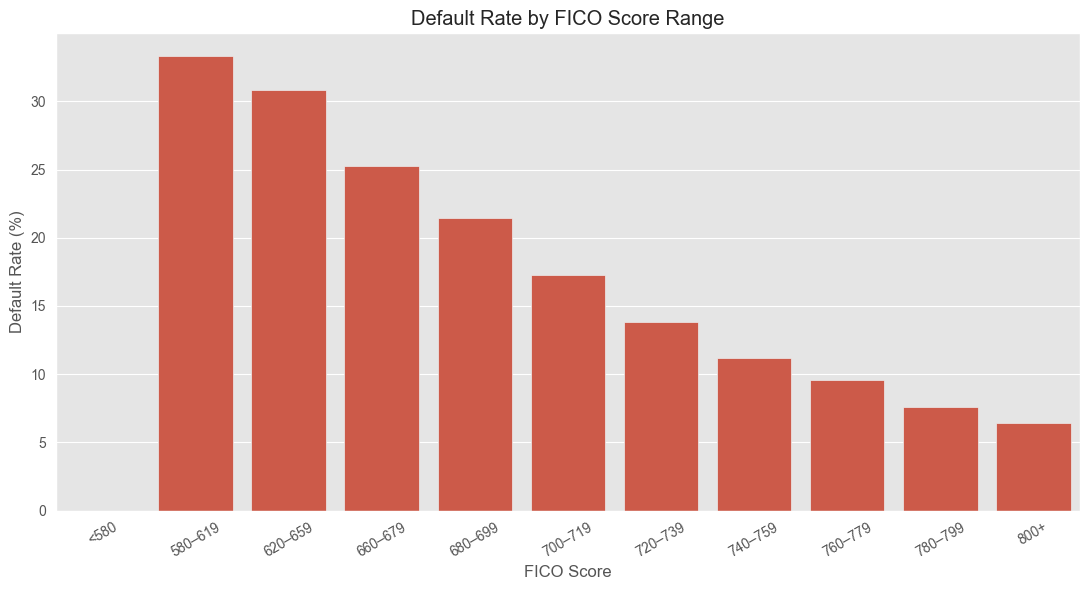

In [49]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=fico_summary.reset_index(),
    x="fico_band",
    y="default_rate",
)

plt.title("Default Rate by FICO Score Range")
plt.xlabel("FICO Score")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Observations

- FICO score shows a strong and approximately monotonic relationship with
  observed default risk.
- Default rates decline consistently as FICO score increases.
- Default rate is **25.30%** for borrowers with FICO scores between 660–679,
  compared with **6.42%** for borrowers with scores of 800 or above.
- The relationship remains directionally consistent across the major FICO
  ranges, suggesting that higher credit scores are associated with lower
  observed default risk.
- Very low FICO ranges contain very few observations and therefore their
  default rates should not be interpreted as stable population estimates.

### Business Implications

FICO score is a strong indicator of borrower credit risk. Higher-credit-quality
borrowers exhibit substantially lower observed default rates.

This supports the use of credit score as a major risk-discrimination variable
in the underwriting model.

## Interest Rate vs Default

Interest rate reflects the pricing assigned to a loan and may incorporate
perceived borrower and loan risk.

This analysis examines whether observed default rates increase with interest
rate and whether the relationship is approximately monotonic.

In [51]:
display(
    model_df["int_rate"].describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
)

count    1.348099e+06
mean     1.324156e+01
std      4.765685e+00
min      5.310000e+00
1%       5.320000e+00
5%       6.490000e+00
25%      9.750000e+00
50%      1.274000e+01
75%      1.599000e+01
95%      2.215000e+01
99%      2.630000e+01
max      3.099000e+01
Name: int_rate, dtype: float64

In [52]:
interest_bins = [
    0,
    6,
    8,
    10,
    12,
    14,
    16,
    18,
    20,
    22,
    24,
    np.inf,
]

interest_labels = [
    "<6%",
    "6–8%",
    "8–10%",
    "10–12%",
    "12–14%",
    "14–16%",
    "16–18%",
    "18–20%",
    "20–22%",
    "22–24%",
    "24%+",
]

model_df["interest_rate_band"] = pd.cut(
    model_df["int_rate"],
    bins=interest_bins,
    labels=interest_labels,
    right=False,
)

In [53]:
interest_summary = model_df.groupby("interest_rate_band", observed=True).agg(
    loans=("default", "size"),
    defaults=("default", "sum"),
    default_rate=("default", "mean"),
)

interest_summary["default_rate"] = (interest_summary["default_rate"] * 100).round(2)

display(interest_summary)

,loans,defaults,default_rate
interest_rate_band,,,
<6%,32873,1138,3.46
6–8%,175409,10997,6.27
8–10%,167206,18530,11.08
10–12%,215845,32615,15.11
12–14%,247526,49776,20.11
14–16%,173698,41147,23.69
16–18%,129981,38011,29.24
18–20%,95347,32350,33.93
20–22%,42556,15349,36.07


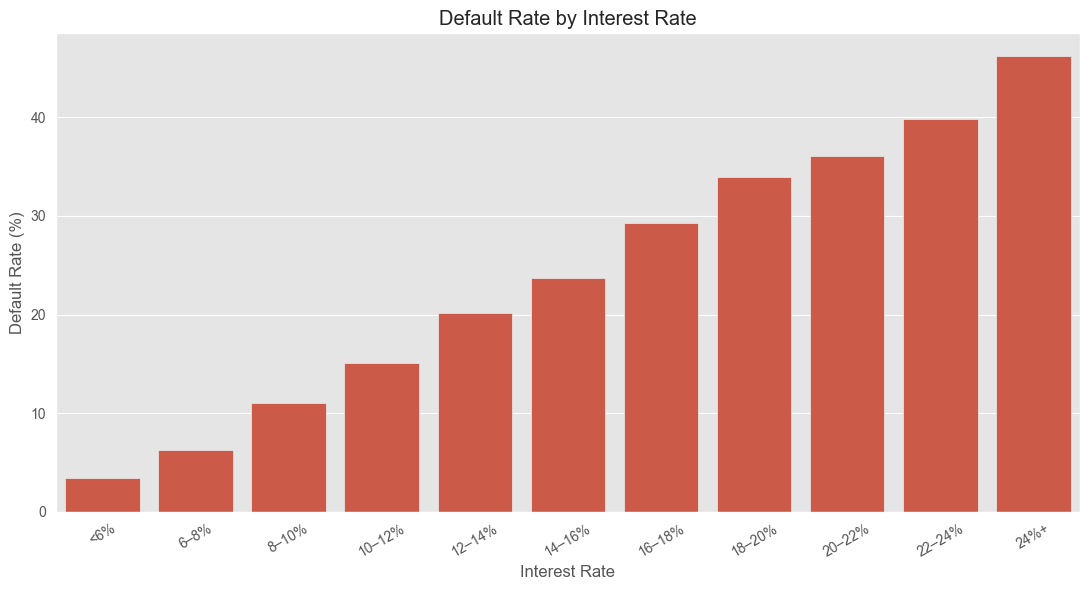

In [54]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=interest_summary.reset_index(),
    x="interest_rate_band",
    y="default_rate",
)

plt.title("Default Rate by Interest Rate")
plt.xlabel("Interest Rate")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Observations

- Default rate increases consistently as the interest rate increases.
- Loans with interest rates below 6% have an observed default rate of only
  **3.46%**.
- Default rates increase substantially through the middle interest-rate ranges,
  reaching **23.69%** for loans between 14% and 16%.
- The default rate continues increasing to **39.79%** for loans between 22% and
  24%.
- Loans with interest rates of 24% or higher have the highest observed default
  rate at **46.18%**.
- The relationship is strongly monotonic: higher interest rates are consistently
  associated with higher observed default rates.
- The major interest-rate bands contain substantial numbers of observations,
  making the overall pattern considerably more reliable than the very small
  low-FICO bands observed earlier.

### Business Implications

Interest rate is strongly associated with observed credit risk. Higher-priced
loans exhibit substantially higher default rates, indicating that loan pricing
captures meaningful differences in borrower and/or loan risk.

This makes interest rate an important variable for understanding the credit-risk
profile of a loan.

### Modeling Implications

Interest rate exhibits a strong monotonic relationship with the default outcome
and therefore warrants further evaluation as a predictive feature. Its inclusion
must, however, be validated against the model's prediction point because the rate
is assigned during underwriting and may not be available for an earlier-stage
approval decision.

## Debt-to-Income Ratio vs Default

Debt-to-income ratio (DTI) measures the borrower's existing debt burden
relative to income.

This analysis examines whether higher DTI is associated with higher observed
default risk and whether the relationship remains consistent across DTI ranges.

In [56]:
display(
    model_df["dti"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
)

count    1.347725e+06
mean     1.827425e+01
std      1.115549e+01
min     -1.000000e+00
1%       1.770000e+00
5%       4.970000e+00
25%      1.179000e+01
50%      1.761000e+01
75%      2.405000e+01
95%      3.298000e+01
99%      3.847000e+01
max      9.990000e+02
Name: dti, dtype: float64

In [57]:
display(model_df.loc[model_df["dti"] < 0, ["dti", "default"]].head())

print("Negative DTI:", (model_df["dti"] < 0).sum())
print("Missing DTI:", model_df["dti"].isna().sum())

,dti,default
1014615,-1.0,0
1681348,-1.0,0


Negative DTI: 2
Missing DTI: 374


In [58]:
dti_bins = [
    0,
    5,
    10,
    15,
    20,
    25,
    30,
    35,
    40,
    50,
    60,
    np.inf,
]

dti_labels = [
    "<5%",
    "5–10%",
    "10–15%",
    "15–20%",
    "20–25%",
    "25–30%",
    "30–35%",
    "35–40%",
    "40–50%",
    "50–60%",
    "60%+",
]

model_df["dti_band"] = pd.cut(
    model_df["dti"],
    bins=dti_bins,
    labels=dti_labels,
    right=False,
)

In [59]:
dti_summary = model_df.groupby("dti_band", observed=True).agg(
    loans=("default", "size"),
    defaults=("default", "sum"),
    default_rate=("default", "mean"),
)

dti_summary["default_rate"] = (dti_summary["default_rate"] * 100).round(2)

display(dti_summary)

,loans,defaults,default_rate
dti_band,,,
<5%,68005,10065,14.80
5–10%,178547,26735,14.97
10–15%,273509,45449,16.62
15–20%,289640,55148,19.04
20–25%,241773,52605,21.76
25–30%,167564,41752,24.92
30–35%,93659,26730,28.54
35–40%,28256,8737,30.92
40–50%,3993,1271,31.83


### Observations

- Default rate increases consistently as DTI increases from below 5% through
  the 35–40% range.
- Default rate is **14.80%** for DTI below 5% and rises to **30.92%** for
  DTI between 35% and 40%.
- The increase is substantial: borrowers in the 35–40% range have more than
  twice the observed default rate of borrowers below 5%.
- The 40–50% range has the highest observed default rate at **31.83%**.
- Default rate declines to **28.53%** and **28.80%** in the 50–60% and 60%+
  ranges, respectively.
- The high-DTI tail contains very few observations compared with the main
  population: only **3,993 loans** fall in the 40–50% range, **1,062** in
  50–60%, and **1,715** above 60%.
- Therefore, the overall relationship is strongly positive, but the apparent
  decline beyond 50% should not be interpreted as evidence that extremely high
  DTI reduces default risk.

### Business Implications

Higher borrower debt burden is strongly associated with higher observed default
risk, particularly across the main DTI distribution. DTI therefore provides
meaningful information about borrower repayment capacity.

### Modeling Implications

DTI should be retained as a candidate predictive feature. The relationship is
nonlinear in the extreme tail, but the small number of observations at very
high DTI values makes the tail behavior unreliable.

The raw numerical representation should initially be preserved, with alternative
transformations or bands evaluated during feature engineering.

## Delinquencies in the Last 2 Years vs Default

Recent delinquency history is an important indicator of a borrower's past
repayment behavior.

This analysis examines whether the number of delinquencies reported during
the previous two years is associated with observed default risk.

In [62]:
display(model_df["delinq_2yrs"].describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]))

print("Missing:", model_df["delinq_2yrs"].isna().sum())

count    1.348070e+06
mean     3.176326e-01
std      8.777443e-01
min      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
90%      1.000000e+00
95%      2.000000e+00
99%      4.000000e+00
max      3.900000e+01
Name: delinq_2yrs, dtype: float64

Missing: 29


In [63]:
display(
    model_df["delinq_2yrs"].value_counts(dropna=False).sort_index().to_frame("loans")
)

,loans
delinq_2yrs,
0.0,1088396
1.0,172610
2.0,50512
3.0,18363
4.0,8133
5.0,4187
6.0,2304
7.0,1291
8.0,760


In [64]:
delinq_summary = model_df.groupby("delinq_2yrs", dropna=False).agg(
    loans=("default", "size"),
    defaults=("default", "sum"),
    default_rate=("default", "mean"),
)

delinq_summary["default_rate"] = (delinq_summary["default_rate"] * 100).round(2)

display(delinq_summary)

,loans,defaults,default_rate
delinq_2yrs,,,
0.0,1088396,213619,19.63
1.0,172610,35990,20.85
2.0,50512,11226,22.22
3.0,18363,4248,23.13
4.0,8133,1898,23.34
5.0,4187,992,23.69
6.0,2304,521,22.61
7.0,1291,319,24.71
8.0,760,174,22.89


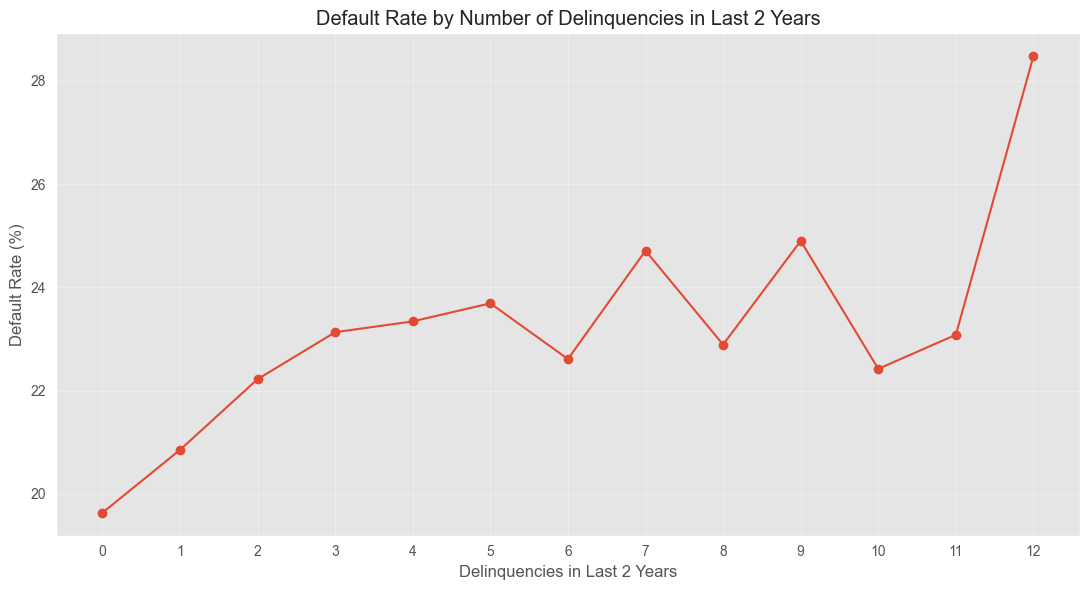

In [65]:
delinq_plot = delinq_summary.loc[delinq_summary.index <= 12].reset_index()

plt.figure(figsize=(11, 6))

plt.plot(
    delinq_plot["delinq_2yrs"],
    delinq_plot["default_rate"],
    marker="o",
)

plt.title("Default Rate by Number of Delinquencies in Last 2 Years")
plt.xlabel("Delinquencies in Last 2 Years")
plt.ylabel("Default Rate (%)")
plt.xticks(range(0, 13))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Observations

- Default rate generally increases as the number of delinquencies in the
  previous two years increases.
- Borrowers with no recorded delinquencies have a default rate of **19.63%**.
- The rate increases to **23.69%** for borrowers with five delinquencies.
- Beyond this point, the relationship becomes substantially noisier because
  the number of observations in each category becomes very small.
- For example, categories above 15 delinquencies generally contain fewer than
  100 observations, making their individual default rates unreliable.
- The overall pattern therefore supports a positive association between recent
  delinquency history and default risk, but the extreme tail should not be
  interpreted independently.

## Annual Income vs Default

Annual income is a key measure of borrower financial capacity and may influence
the borrower's ability to service debt.

This analysis examines the relationship between annual income and observed
default risk, while accounting for the highly skewed distribution of borrower
income.

In [69]:
model_df["income_band"] = pd.qcut(
    model_df["annual_inc"],
    q=[0, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 1.00],
    duplicates="drop",
)

income_summary = model_df.groupby("income_band", observed=True).agg(
    loans=("default", "size"),
    defaults=("default", "sum"),
    default_rate=("default", "mean"),
)

income_summary["default_rate"] = (income_summary["default_rate"] * 100).round(2)

display(income_summary)

,loans,defaults,default_rate
income_band,,,
"(-0.001, 34000.0]",136413,32844,24.08
"(34000.0, 45750.0]",200614,45662,22.76
"(45750.0, 65000.0]",363298,76841,21.15
"(65000.0, 90000.0]",313008,59789,19.10
"(90000.0, 125000.0]",202630,34246,16.90
"(125000.0, 155000.0]",65252,10210,15.65
"(155000.0, 10999200.0]",66880,9768,14.61


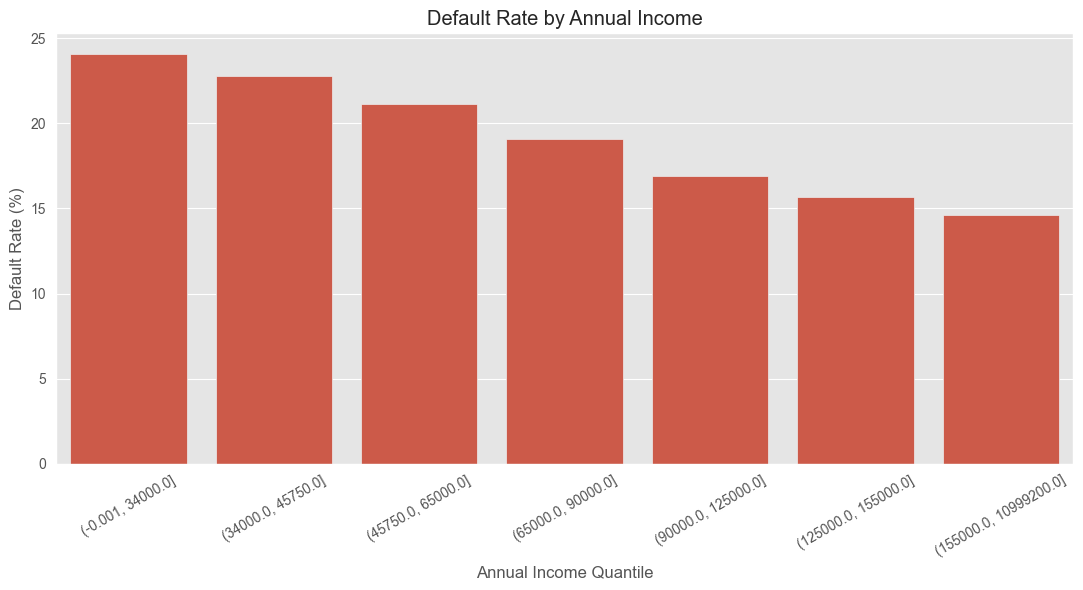

In [70]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=income_summary.reset_index(),
    x="income_band",
    y="default_rate",
)

plt.title("Default Rate by Annual Income")
plt.xlabel("Annual Income Quantile")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Observations

- Default rate decreases consistently as annual income increases.
- Borrowers earning below approximately **$34,000** have the highest observed
  default rate at **24.08%**.
- Default rate declines to **19.10%** for borrowers earning between
  approximately **$65,000 and $90,000**.
- Borrowers in the highest-income band have the lowest observed default rate at
  **14.61%**.
- The relationship suggests that higher borrower income is associated with
  lower observed default risk.
- The highest-income band spans a very wide range because of the strongly
  right-skewed income distribution; therefore, the band should be interpreted
  as a broad upper-income group rather than a uniform income range.

### Modeling Implications

Annual income should be retained as a candidate predictive feature. Its
relationship with default is directionally consistent, although the strong
right skew of the variable should be considered during feature engineering and
model development.

The raw numerical representation should initially be preserved, with
transformations such as logarithmic scaling evaluated later if appropriate.

## Revolving Credit Utilization vs Default

Revolving credit utilization measures the proportion of available revolving
credit currently being used by the borrower.

This analysis examines whether higher revolving utilization is associated with
higher observed default risk.

In [71]:
revol_util_bins = [
    0,
    10,
    20,
    30,
    40,
    50,
    60,
    70,
    80,
    90,
    100,
    np.inf,
]

revol_util_labels = [
    "<10%",
    "10–20%",
    "20–30%",
    "30–40%",
    "40–50%",
    "50–60%",
    "60–70%",
    "70–80%",
    "80–90%",
    "90–100%",
    "100%+",
]

model_df["revol_util_band"] = pd.cut(
    model_df["revol_util"],
    bins=revol_util_bins,
    labels=revol_util_labels,
    right=False,
)

revol_util_summary = model_df.groupby("revol_util_band", observed=True).agg(
    loans=("default", "size"),
    defaults=("default", "sum"),
    default_rate=("default", "mean"),
)

revol_util_summary["default_rate"] = (revol_util_summary["default_rate"] * 100).round(2)

display(revol_util_summary)

,loans,defaults,default_rate
revol_util_band,,,
<10%,64341,9448,14.68
10–20%,89163,13512,15.15
20–30%,128691,21931,17.04
30–40%,165784,31000,18.70
40–50%,183321,36626,19.98
50–60%,189301,39815,21.03
60–70%,176459,38210,21.65
70–80%,151397,33345,22.02
80–90%,116693,26109,22.37


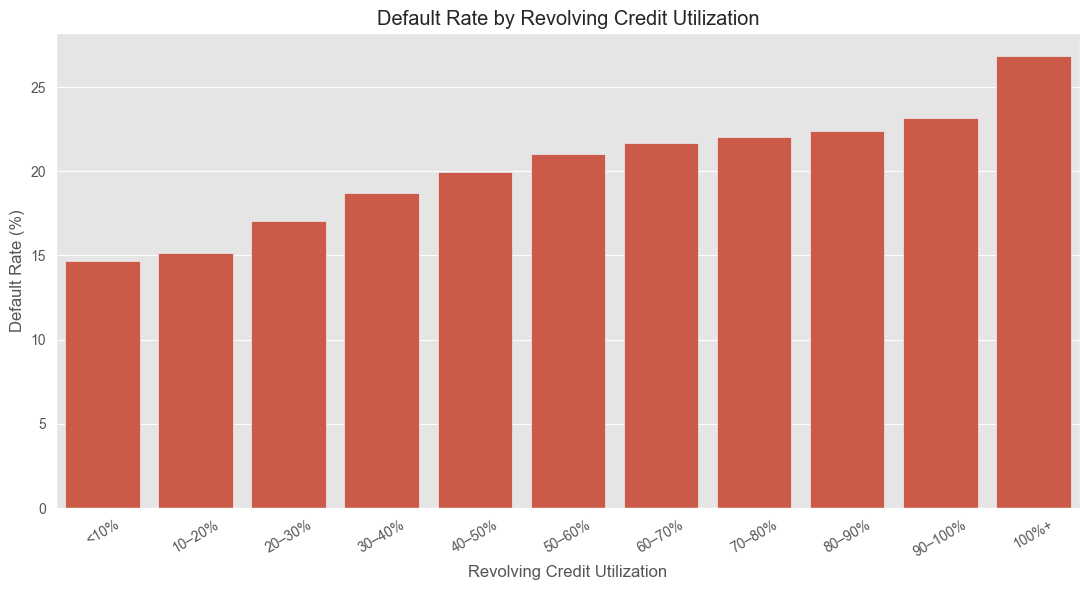

In [72]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=revol_util_summary.reset_index(),
    x="revol_util_band",
    y="default_rate",
)

plt.title("Default Rate by Revolving Credit Utilization")
plt.xlabel("Revolving Credit Utilization")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Observations

- Default rate increases consistently as revolving credit utilization increases.
- Borrowers with utilization below 10% have an observed default rate of
  **14.68%**.
- Default rate rises steadily through the utilization range, reaching
  **23.14%** for borrowers with 90–100% utilization.
- Loans with utilization above 100% have the highest observed default rate at
  **26.85%**, although this group contains substantially fewer observations.
- The overall monotonic relationship indicates that higher revolving credit
  utilization is associated with higher observed default risk.

### Modeling Implications

Revolving credit utilization should be retained as a candidate predictive
feature. Its approximately monotonic relationship with default suggests that
the raw numerical representation should initially be preserved, with alternative
transformations or representations evaluated during feature engineering.

## Recent Credit Inquiries vs Default

The number of credit inquiries during the previous six months provides an
indication of recent credit-seeking activity.

This analysis examines whether recent inquiry frequency is associated with
observed default risk.

In [73]:
inq_summary = (
    model_df.assign(
        inq_6m_band=model_df["inq_last_6mths"].where(
            model_df["inq_last_6mths"] <= 5,
            6,
        )
    )
    .groupby("inq_6m_band", dropna=False)
    .agg(
        loans=("default", "size"),
        defaults=("default", "sum"),
        default_rate=("default", "mean"),
    )
)

inq_summary.index = inq_summary.index.map(lambda x: "5+" if x == 6 else x)

inq_summary["default_rate"] = (inq_summary["default_rate"] * 100).round(2)

display(inq_summary)

,loans,defaults,default_rate
inq_6m_band,,,
0.0,770762,138129,17.92
1.0,366953,78681,21.44
2.0,136957,32863,24.00
3.0,51789,13614,26.29
4.0,14592,4079,27.95
5.0,5338,1511,28.31
5+,1708,483,28.28


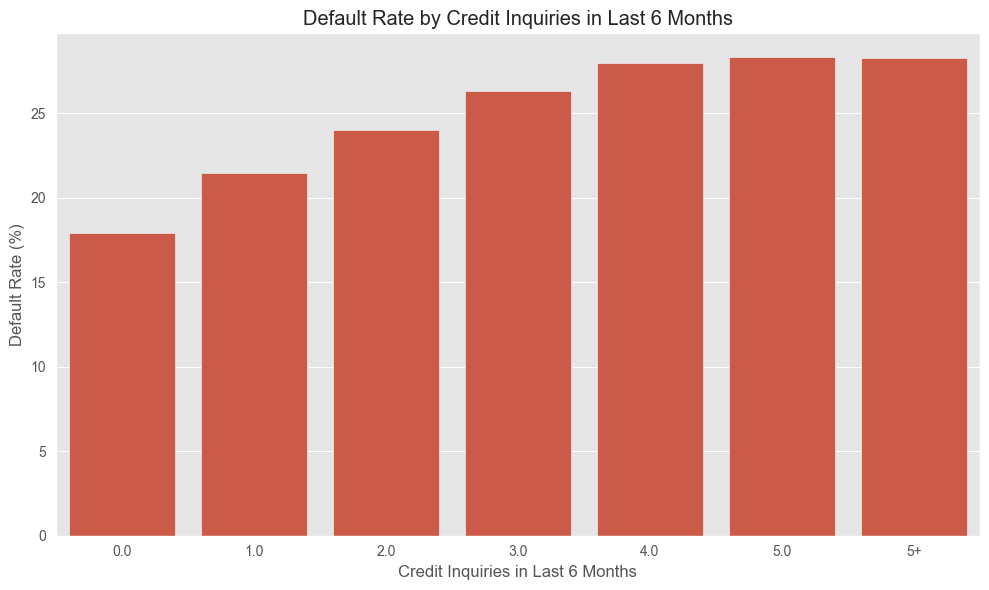

In [74]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=inq_summary.reset_index(),
    x="inq_6m_band",
    y="default_rate",
)

plt.title("Default Rate by Credit Inquiries in Last 6 Months")
plt.xlabel("Credit Inquiries in Last 6 Months")
plt.ylabel("Default Rate (%)")

plt.tight_layout()
plt.show()

### Observations

- Default rate increases consistently as the number of credit inquiries in the
  previous six months increases.
- Borrowers with no recent inquiries have an observed default rate of **17.92%**.
- The default rate rises to **24.00%** for borrowers with two inquiries and
  **28.31%** for borrowers with five inquiries.
- The 5+ inquiry group has a similar default rate of **28.28%**, but contains
  only 1,708 loans, so the individual tail behavior should be interpreted with
  caution.
- Overall, recent credit inquiry activity shows a clear positive association
  with observed default risk.

### Business Implications

Higher recent credit inquiry activity is associated with greater observed
default risk. This may indicate increased recent credit-seeking activity or
greater financial pressure among borrowers.

Recent inquiry behavior therefore provides useful information for assessing
borrower credit risk at the time of underwriting.

### Modeling Implications

`inq_last_6mths` should be retained as a candidate predictive feature. The
relationship is approximately monotonic across the well-populated portion of
the distribution, while the sparse upper tail should be handled carefully
during feature engineering.

## Total Credit Accounts vs Default

The total number of credit accounts provides an indication of the depth of a
borrower's established credit history.

This analysis examines whether the number of total credit accounts is
associated with observed default risk.

In [75]:
total_acc_summary = (
    model_df.assign(
        total_acc_band=pd.qcut(
            model_df["total_acc"],
            q=[0, 0.10, 0.25, 0.50, 0.75, 0.90, 1.00],
            duplicates="drop",
        )
    )
    .groupby("total_acc_band", observed=True)
    .agg(
        loans=("default", "size"),
        defaults=("default", "sum"),
        default_rate=("default", "mean"),
    )
)

total_acc_summary["default_rate"] = (total_acc_summary["default_rate"] * 100).round(2)

display(total_acc_summary)

,loans,defaults,default_rate
total_acc_band,,,
"(0.999, 11.0]",146033,30948,21.19
"(11.0, 16.0]",204272,42719,20.91
"(16.0, 23.0]",335680,66875,19.92
"(23.0, 32.0]",347647,67579,19.44
"(32.0, 41.0]",187794,36201,19.28
"(41.0, 176.0]",126644,25035,19.77


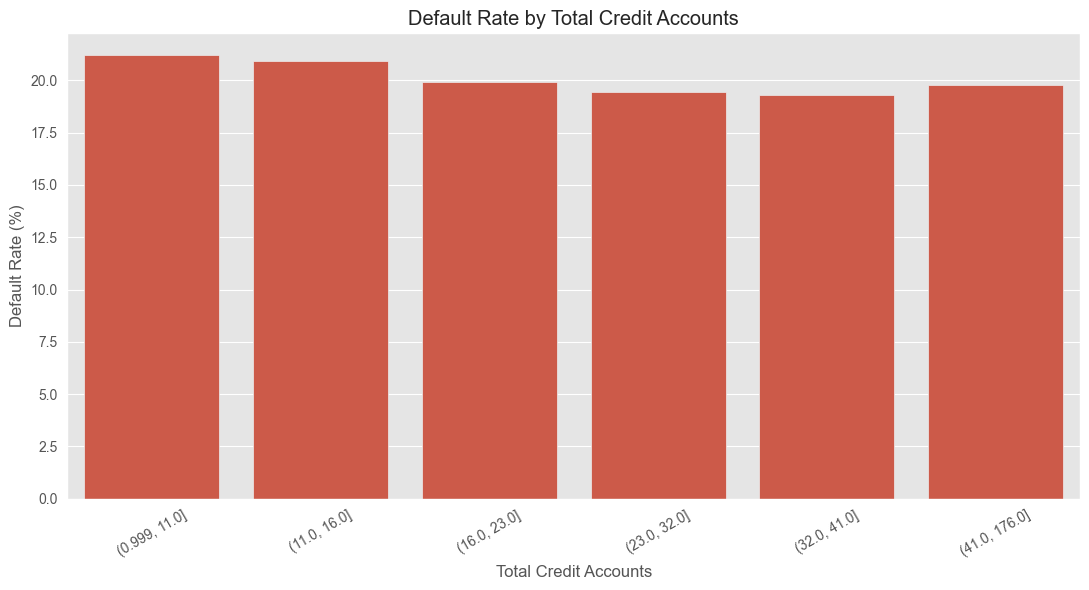

In [76]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=total_acc_summary.reset_index(),
    x="total_acc_band",
    y="default_rate",
)

plt.title("Default Rate by Total Credit Accounts")
plt.xlabel("Total Credit Accounts")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Observations

- Default rate generally decreases as the number of total credit accounts
  increases from the lowest account-count range.
- Borrowers with 11 or fewer total accounts have the highest observed default
  rate at **21.19%**.
- Default rate declines to **19.28%** for borrowers with 33–41 accounts.
- The highest-account group shows a slight increase to **19.77%**, indicating
  that the relationship is not strictly monotonic across the entire range.
- The overall difference in default rates is relatively small compared with
  features such as FICO, interest rate, DTI, and recent credit inquiries.
- The results therefore suggest a weak relationship between total credit
  account depth and observed default risk.

### Business Implications

A deeper established credit history appears to be associated with slightly
lower observed default risk, particularly among borrowers with relatively few
credit accounts.

However, the small variation in default rates suggests that total account
count alone provides limited information about borrower risk compared with
more direct indicators of credit quality and recent credit behavior.

### Modeling Implications

`total_acc` may be retained as a candidate predictive feature, but its
incremental predictive value should be evaluated against other credit-history
variables. The relatively weak and non-monotonic relationship suggests that
it should not be prioritized for manual transformation based on EDA alone.

## Loan Term vs Default

Loan term represents the contractual repayment duration of the loan.

This analysis examines whether observed default risk differs between loans with
different repayment terms.

In [77]:
term_summary = model_df.groupby("term", dropna=False).agg(
    loans=("default", "size"),
    defaults=("default", "sum"),
    default_rate=("default", "mean"),
)

term_summary["default_rate"] = (term_summary["default_rate"] * 100).round(2)

display(term_summary)

,loans,defaults,default_rate
term,,,
36 months,1023206,163926,16.02
60 months,324893,105434,32.45


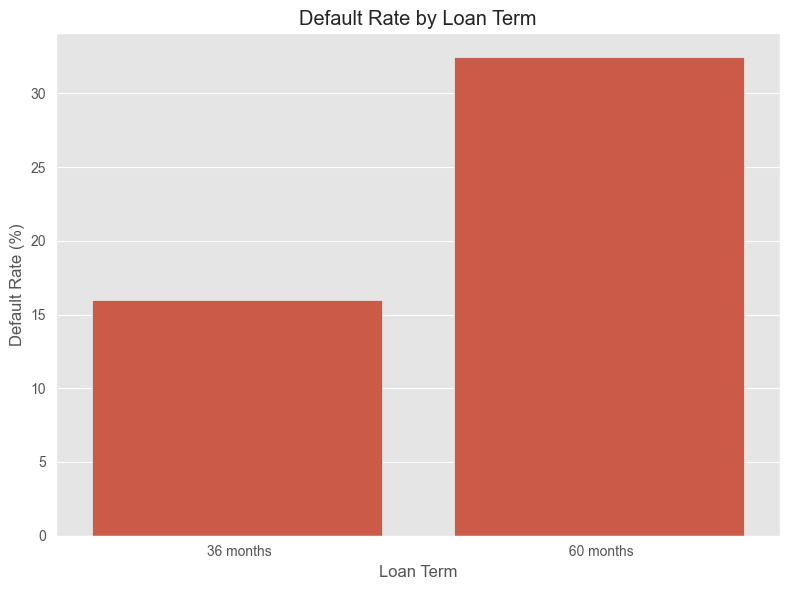

In [78]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=term_summary.reset_index(),
    x="term",
    y="default_rate",
)

plt.title("Default Rate by Loan Term")
plt.xlabel("Loan Term")
plt.ylabel("Default Rate (%)")

plt.tight_layout()
plt.show()

### Observations

- Loan term shows a strong relationship with observed default risk.
- 36-month loans have an observed default rate of **16.02%**.
- 60-month loans have an observed default rate of **32.45%**, approximately twice
  the rate of 36-month loans.
- The substantial difference suggests that longer repayment horizons are
  associated with materially higher observed default risk.
- Both term categories contain large numbers of observations, making this
  relationship considerably more reliable than relationships observed in sparse
  categories.

### Business Implications

Longer-term loans expose borrowers to repayment obligations over a longer
period and are associated with substantially higher observed default risk.
Loan term therefore represents an important dimension of credit-risk
differentiation and should be considered when assessing the risk and pricing
of a loan.

### Modeling Implications

`term` should be retained as a candidate predictive feature. Given its
categorical nature and the substantial difference in observed default rates,
the variable should be represented explicitly during preprocessing rather than
treated as a continuous numerical variable.

## Loan Purpose vs Default

Loan purpose describes the intended use of the borrowed funds and may capture
differences in borrower circumstances and underlying credit risk.

This analysis examines whether observed default rates differ across loan
purposes.

In [79]:
purpose_summary = model_df.groupby("purpose", dropna=False).agg(
    loans=("default", "size"),
    defaults=("default", "sum"),
    default_rate=("default", "mean"),
)

purpose_summary["default_rate"] = (purpose_summary["default_rate"] * 100).round(2)

purpose_summary = purpose_summary.sort_values(
    "default_rate",
    ascending=False,
)

display(purpose_summary)

,loans,defaults,default_rate
purpose,,,
small_business,15577,4652,29.86
renewable_energy,936,222,23.72
moving,9526,2229,23.40
house,7298,1599,21.91
medical,15614,3411,21.85
debt_consolidation,781442,165327,21.16
other,78301,16508,21.08
educational,423,88,20.80
vacation,9084,1744,19.20


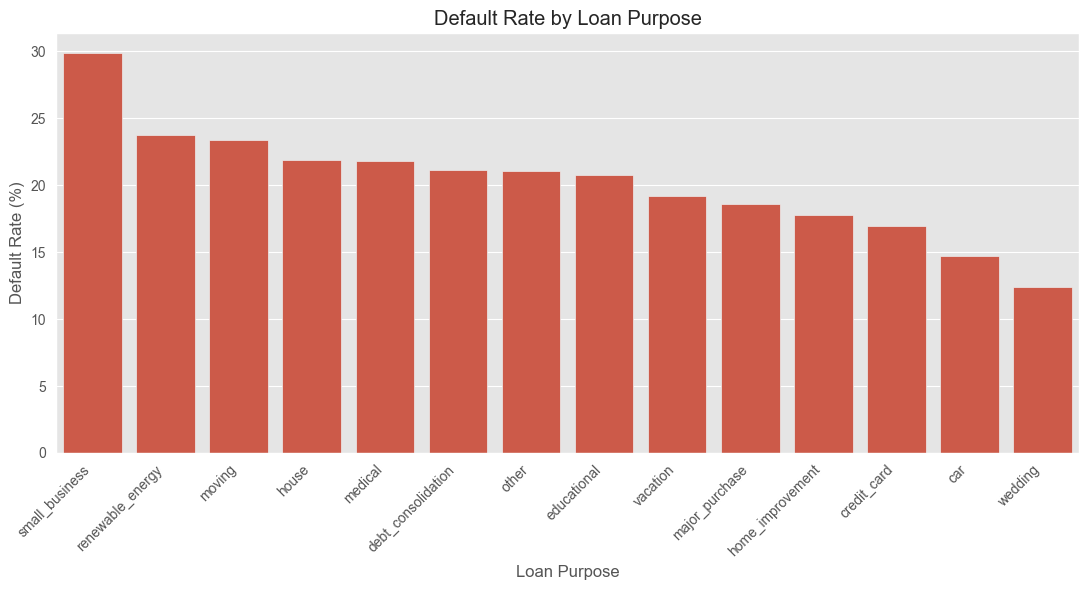

In [80]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=purpose_summary.reset_index(),
    x="purpose",
    y="default_rate",
)

plt.title("Default Rate by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Observations

- Observed default rates vary substantially across loan purposes.
- `small_business` has the highest observed default rate at **29.86%**, followed
  by `renewable_energy` at **23.72%** and `moving` at **23.40%**.
- `debt_consolidation`, despite being by far the largest category, has a
  default rate of **21.16%**.
- `car` loans have a relatively low observed default rate of **14.72%**, while
  `wedding` loans have the lowest at **12.43%**.
- Some categories have very small populations, particularly `educational`,
  `renewable_energy`, and `wedding`. Their individual default rates should
  therefore be interpreted with greater caution.
- Overall, loan purpose shows meaningful differences in observed default risk,
  although the relationship is categorical rather than monotonic.

### Business Implications

Loan purpose appears to capture differences in the risk profile of borrowers
and/or the circumstances surrounding borrowing. Certain purposes, particularly
small-business loans, exhibit substantially higher observed default rates than
others.

Loan purpose can therefore provide useful contextual information during
underwriting, but category-level risk should be interpreted alongside borrower
credit quality and loan characteristics rather than in isolation.

### Modeling Implications

`purpose` should be retained as a candidate categorical predictive feature.
Because several categories are relatively small, category frequency and
potential rare-category handling should be considered during preprocessing.
The observed differences should be validated against other borrower and loan
characteristics before attributing independent predictive power to loan purpose.

## Home Ownership vs Default

Home ownership describes the borrower's reported housing status and may capture
differences in financial circumstances and borrower stability.

This analysis examines whether observed default rates differ across housing
status categories.

In [81]:
home_ownership_summary = model_df.groupby("home_ownership", dropna=False).agg(
    loans=("default", "size"),
    defaults=("default", "sum"),
    default_rate=("default", "mean"),
)

home_ownership_summary["default_rate"] = (
    home_ownership_summary["default_rate"] * 100
).round(2)

home_ownership_summary = home_ownership_summary.sort_values(
    "default_rate",
    ascending=False,
)

display(home_ownership_summary)

,loans,defaults,default_rate
home_ownership,,,
RENT,535699,124441,23.23
OTHER,182,38,20.88
OWN,145027,29921,20.63
ANY,286,56,19.58
MORTGAGE,666852,114896,17.23
NONE,53,8,15.09


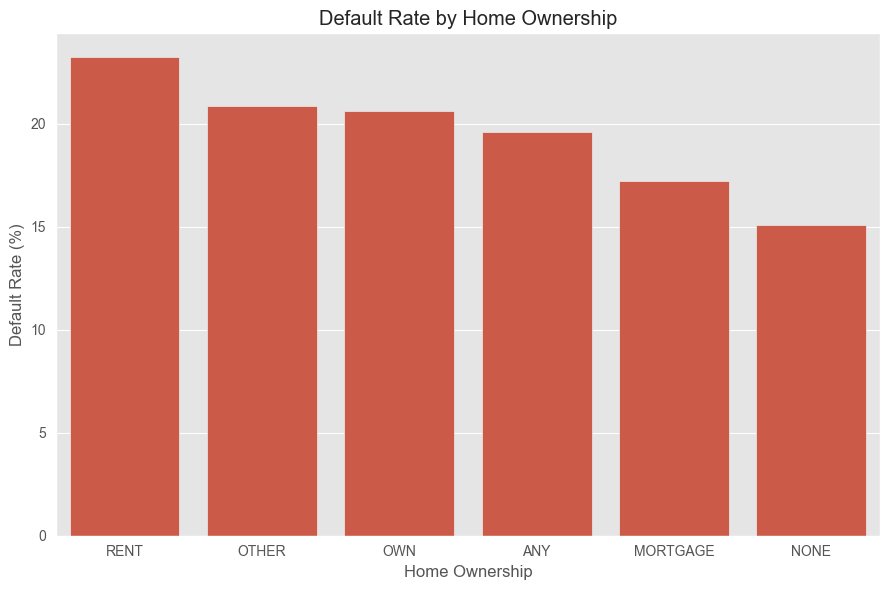

In [82]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=home_ownership_summary.reset_index(),
    x="home_ownership",
    y="default_rate",
)

plt.title("Default Rate by Home Ownership")
plt.xlabel("Home Ownership")
plt.ylabel("Default Rate (%)")

plt.tight_layout()
plt.show()

### Observations

- `RENT` borrowers have the highest default rate among the major housing
  categories at **23.23%**.
- `OWN` borrowers have a lower observed default rate of **20.63%**.
- `MORTGAGE` borrowers have the lowest default rate among the major categories
  at **17.23%**.
- The `OTHER`, `ANY`, and `NONE` categories contain very few observations
  relative to `RENT`, `OWN`, and `MORTGAGE`, so their observed default rates
  are not reliable indicators of population-level risk.
- Overall, housing status shows a meaningful difference in observed default
  rates, with renters exhibiting higher risk than borrowers who own or
  mortgage their homes.

### Business Implications

Home ownership status appears to capture differences in borrowers' financial
circumstances and is associated with observed default risk. Borrowers who rent
show higher default rates than borrowers with a mortgage or owned property.

However, housing status should be interpreted as a contextual risk indicator
rather than a standalone measure of creditworthiness, since the observed
relationship may reflect differences in income, credit quality, debt burden,
and other borrower characteristics.

### Modeling Implications

`home_ownership` should be retained as a candidate categorical predictive
feature. Rare categories should be handled carefully during preprocessing,
while the dominant categories (`RENT`, `OWN`, and `MORTGAGE`) provide the
most reliable evidence of the relationship.

## Verification Status vs Default

Verification status indicates how the borrower's reported financial
information was treated during the lending process.

This analysis examines whether observed default rates differ across
verification-status categories.

In [83]:
verification_summary = model_df.groupby("verification_status", dropna=False).agg(
    loans=("default", "size"),
    defaults=("default", "sum"),
    default_rate=("default", "mean"),
)

verification_summary["default_rate"] = (
    verification_summary["default_rate"] * 100
).round(2)

verification_summary = verification_summary.sort_values(
    "default_rate",
    ascending=False,
)

display(verification_summary)

,loans,defaults,default_rate
verification_status,,,
Verified,418979,99976,23.86
Source Verified,521579,109330,20.96
Not Verified,407541,60054,14.74


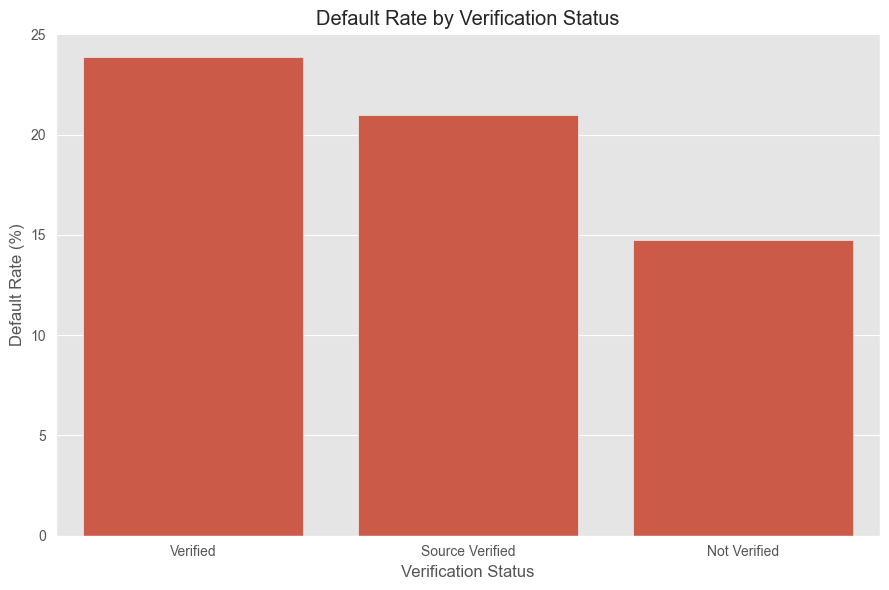

In [84]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=verification_summary.reset_index(),
    x="verification_status",
    y="default_rate",
)

plt.title("Default Rate by Verification Status")
plt.xlabel("Verification Status")
plt.ylabel("Default Rate (%)")

plt.tight_layout()
plt.show()

### Observations

- Verification status shows a clear difference in observed default rates across
  the three major categories.
- `Verified` loans have the highest observed default rate at **23.86%**.
- `Source Verified` loans have a lower default rate of **20.96%**.
- `Not Verified` loans have the lowest observed default rate at **14.74%**.
- The categories all contain substantial numbers of observations, so the
  differences are not driven by extremely small groups.
- The relationship is therefore clearly associated with observed default risk,
  but it should not be interpreted as evidence that verification itself causes
  higher default risk.

### Business Implications

Verification status may capture differences in borrower profiles, reported
financial characteristics, underwriting practices, or the types of loans for
which additional verification was required. The higher default rate among
verified borrowers therefore provides potentially useful risk information,
but the relationship may reflect underlying differences between borrower
populations rather than the act of verification itself.

### Modeling Implications

`verification_status` should be retained as a candidate categorical predictive
feature. Its relationship with default should be evaluated alongside correlated
borrower characteristics such as income, DTI, and credit quality to determine
whether it provides incremental predictive information.

## Employment Length vs Default

Employment length represents the reported duration of the borrower's current
employment and may provide information about income stability.

This analysis examines whether observed default rates differ across employment
tenure categories.

In [85]:
emp_length_summary = model_df.groupby("emp_length", dropna=False).agg(
    loans=("default", "size"),
    defaults=("default", "sum"),
    default_rate=("default", "mean"),
)

emp_length_summary["default_rate"] = (emp_length_summary["default_rate"] * 100).round(2)

display(emp_length_summary)

,loans,defaults,default_rate
emp_length,,,
1 year,88843,18290,20.59
10+ years,442679,83223,18.80
2 years,122100,24205,19.82
3 years,107868,21563,19.99
4 years,80763,15958,19.76
5 years,84326,16545,19.62
6 years,62879,12185,19.38
7 years,59724,11652,19.51
8 years,60811,12135,19.96


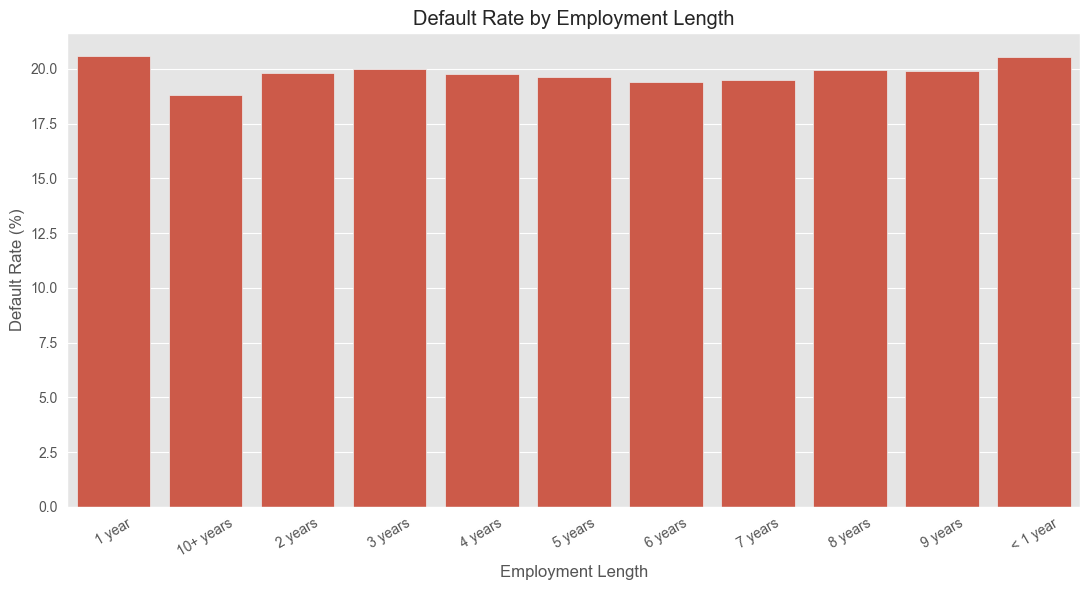

In [86]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=emp_length_summary.reset_index(),
    x="emp_length",
    y="default_rate",
)

plt.title("Default Rate by Employment Length")
plt.xlabel("Employment Length")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Observations

- Among borrowers with reported employment length, default rates remain
  relatively close to one another, ranging from **18.80%** for 10+ years to
  **20.59%** for 1 year.
- Borrowers with less than one year of employment have a default rate of
  **20.54%**, while borrowers with 10+ years have a lower rate of **18.80%**.
- The relationship between reported employment length and default is therefore
  relatively weak and does not show a strong monotonic pattern.
- The missing employment-length group has a substantially higher default rate
  of **26.93%**, making missingness itself potentially informative.
- The missing group is also sufficiently large at **78,550 loans** that this
  pattern should not be dismissed as a tiny-category artifact.

### Business Implications

Reported employment tenure provides only limited differentiation in observed
default risk among borrowers with known employment lengths. However, borrowers
for whom employment length is unavailable exhibit substantially higher observed
default risk.

This may indicate that missing employment information carries information
about borrower or application characteristics and should therefore not
automatically be treated as equivalent to an ordinary employment category.

### Modeling Implications

`emp_length` should be retained as a candidate predictive feature, but its
relationship should not be modeled as strongly monotonic based on EDA alone.
The substantial difference in the missing group suggests that missingness
should be handled explicitly during preprocessing rather than automatically
imputed without preserving the missing-information signal.

## Application Type vs Default

Application type indicates whether the loan application is associated with an
individual borrower or a joint application.

This analysis examines whether observed default rates differ across application
types.

In [87]:
application_type_summary = model_df.groupby("application_type", dropna=False).agg(
    loans=("default", "size"),
    defaults=("default", "sum"),
    default_rate=("default", "mean"),
)

application_type_summary["default_rate"] = (
    application_type_summary["default_rate"] * 100
).round(2)

display(application_type_summary)

,loans,defaults,default_rate
application_type,,,
Individual,1322293,263010,19.89
Joint App,25806,6350,24.61


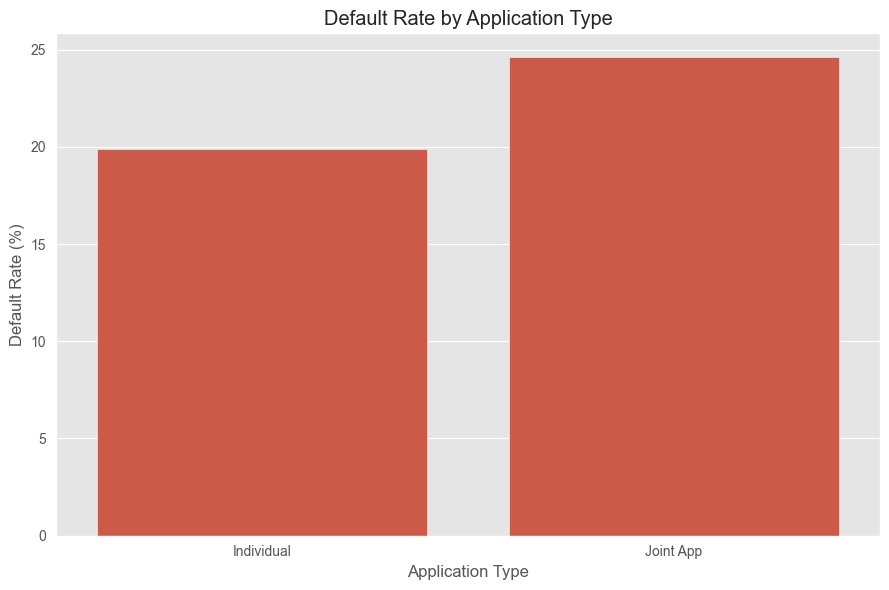

In [88]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=application_type_summary.reset_index(),
    x="application_type",
    y="default_rate",
)

plt.title("Default Rate by Application Type")
plt.xlabel("Application Type")
plt.ylabel("Default Rate (%)")

plt.tight_layout()
plt.show()

### Observations

- `Individual` applications have an observed default rate of **19.89%**.
- `Joint App` applications have a higher observed default rate of **24.61%**.
- The difference is approximately **4.72 percentage points**.
- Individual applications dominate the population with approximately 1.32 million
  loans, while Joint App contains only about 25.8 thousand loans.
- The relationship therefore appears meaningful, but the substantially smaller
  Joint App population should be considered when evaluating its stability.

### Business Implications

Joint applications are associated with higher observed default risk in this
population. This may reflect differences in borrower characteristics,
household financial structures, or the types of loans submitted as joint
applications.

Application structure can therefore provide useful contextual information for
credit-risk assessment, but the observed difference should not be interpreted
as a causal effect of applying jointly.

### Modeling Implications

`application_type` should be retained as a candidate categorical predictive
feature. Its predictive contribution should be evaluated alongside borrower
income, DTI, credit history, and other characteristics to determine whether it
provides incremental information.

## Public Derogatory Records vs Default

Public derogatory records indicate adverse credit events recorded in public
records and provide information about a borrower's previous credit difficulties.

This analysis examines whether the number of public derogatory records is
associated with observed default risk.

In [89]:
pub_rec_summary = (
    model_df.assign(
        pub_rec_band=model_df["pub_rec"].where(
            model_df["pub_rec"] <= 3,
            4,
        )
    )
    .groupby("pub_rec_band", dropna=False)
    .agg(
        loans=("default", "size"),
        defaults=("default", "sum"),
        default_rate=("default", "mean"),
    )
)

pub_rec_summary.index = pub_rec_summary.index.map(lambda x: "3+" if x == 4 else x)

pub_rec_summary["default_rate"] = (pub_rec_summary["default_rate"] * 100).round(2)

display(pub_rec_summary)

,loans,defaults,default_rate
pub_rec_band,,,
0.0,1119921,217402,19.41
1.0,191035,43253,22.64
2.0,24448,5781,23.65
3.0,7403,1682,22.72
3+,5292,1242,23.47


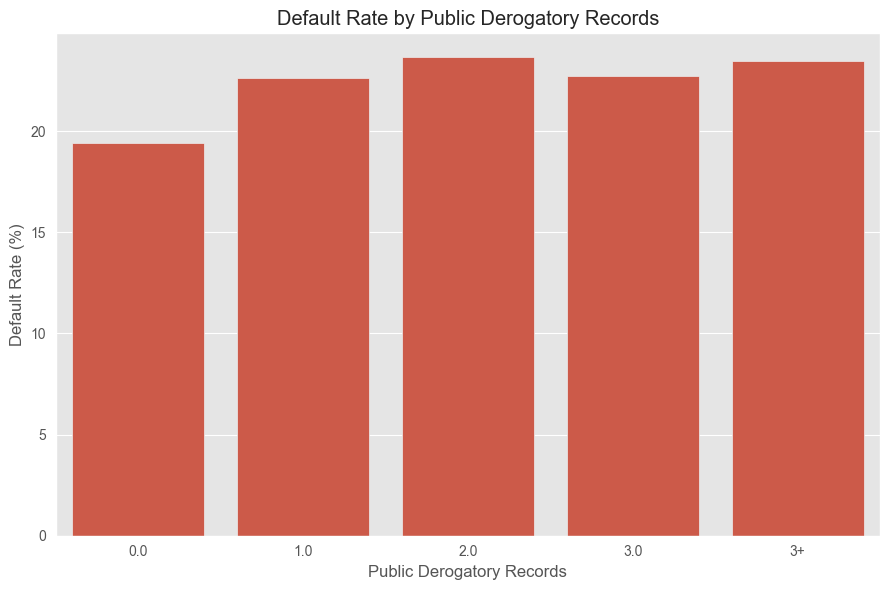

In [90]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=pub_rec_summary.reset_index(),
    x="pub_rec_band",
    y="default_rate",
)

plt.title("Default Rate by Public Derogatory Records")
plt.xlabel("Public Derogatory Records")
plt.ylabel("Default Rate (%)")

plt.tight_layout()
plt.show()

### Observations

- Borrowers with no public derogatory records have an observed default rate of
  **19.41%**.
- The default rate increases to **22.64%** for borrowers with one derogatory
  record and reaches **23.65%** for borrowers with two records.
- The relationship becomes relatively flat beyond two records, with default
  rates of **22.72%** for three records and **23.47%** for the 3+ group.
- The majority of loans belong to the zero-record category, while the higher
  record-count categories contain substantially fewer observations.
- Overall, the presence of public derogatory records is associated with higher
  observed default risk, but the number of records beyond the first few adds
  relatively little additional separation.

### Business Implications

The presence of adverse public credit records indicates a history of credit
difficulty and is associated with elevated observed default risk. However,
additional derogatory records beyond the first few do not appear to produce a
proportionally higher level of observed risk.

This suggests that the existence of adverse credit history may be more
informative than the exact number of records.

### Modeling Implications

`pub_rec` should be retained as a candidate predictive feature. The relatively
weak incremental separation in the upper range suggests that treating the
variable as a simple raw count may not necessarily be optimal; alternative
representations can be evaluated during feature engineering.

## Collections in Previous 12 Months vs Default

Collections activity during the previous twelve months provides an indication
of recent adverse credit events and may capture financial distress that is
relevant to future repayment behavior.

This analysis examines whether recent collection activity is associated with
observed default risk.

In [91]:
collections_summary = (
    model_df.assign(
        collections_band=model_df["collections_12_mths_ex_med"].where(
            model_df["collections_12_mths_ex_med"] <= 2,
            3,
        )
    )
    .groupby("collections_band", dropna=False)
    .agg(
        loans=("default", "size"),
        defaults=("default", "sum"),
        default_rate=("default", "mean"),
    )
)

collections_summary.index = collections_summary.index.map(
    lambda x: "3+" if x == 3 else x
)

collections_summary["default_rate"] = (collections_summary["default_rate"] * 100).round(
    2
)

display(collections_summary)

,loans,defaults,default_rate
collections_band,,,
0.0,1326911,263966,19.89
1.0,19504,4953,25.39
2.0,1292,354,27.40
3+,392,87,22.19


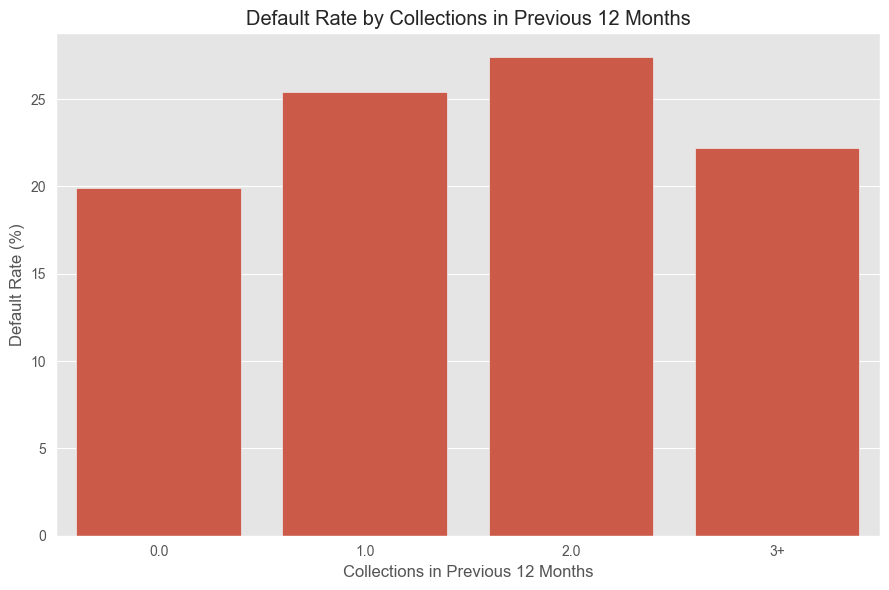

In [92]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=collections_summary.reset_index(),
    x="collections_band",
    y="default_rate",
)

plt.title("Default Rate by Collections in Previous 12 Months")
plt.xlabel("Collections in Previous 12 Months")
plt.ylabel("Default Rate (%)")

plt.tight_layout()
plt.show()

### Observations

- Loans with no collections in the previous 12 months have an observed default
  rate of **19.89%**.
- The default rate increases substantially to **25.39%** for borrowers with one
  collection and **27.40%** for borrowers with two collections.
- The `3+` group has a lower observed default rate of **22.19%**, breaking the
  otherwise increasing pattern; however, this group contains only **392 loans**.
- The large difference between borrowers with zero collections and those with
  one or more collections indicates that the presence of recent collection
  activity is more informative than the exact number of collections.
- Overall, recent collection activity shows a positive association with
  observed default risk.

### Business Implications

Recent collection activity is an indicator of prior financial difficulty and
is associated with materially higher observed default risk. Borrowers with
recent collections may therefore warrant greater credit-risk attention during
underwriting.

The diminishing and unstable pattern in the sparse upper tail suggests that
the existence of recent collection activity may be more useful than relying
heavily on the exact number of collection events.

### Modeling Implications

`collections_12_mths_ex_med` should be retained as a candidate predictive
feature. Because the upper categories are sparse and non-monotonic, alternative
representations such as a binary indicator for the presence of collections may
be evaluated during feature engineering.

# EDA Conclusions

The exploratory analysis established the major structural, target, data-quality,
and feature-level characteristics relevant to credit-risk modeling.

The target population was examined separately from unresolved loan outcomes,
and application-time feature eligibility was considered before interpreting
feature relationships.

The targeted analysis identified several features with meaningful associations
with observed default risk, including FICO score, interest rate, DTI, revolving
utilization, recent credit inquiries, loan term, annual income, delinquency
history, and recent collection activity.

Several categorical variables, including loan purpose, home ownership,
verification status, employment length, and application type, also exhibited
differences in observed default rates across groups.

Not all relationships were strong or monotonic. In particular, total credit
account count and employment length showed relatively weak relationships,
while missing employment information itself exhibited elevated default risk.

The observed relationships describe associations rather than causal effects.
They will therefore be used to guide preprocessing and feature engineering
rather than directly determining the final model specification.

Features identified as requiring prediction-time or business review, particularly
interest rate, will be revisited before final model inclusion.

## EDA → Modeling Decision Summary

| Feature | EDA Relationship | Initial Decision |
|---|---|---|
| loan_amnt | Nonlinear | Retain |
| FICO | Strong negative | Retain |
| int_rate | Strong positive | Review prediction point |
| dti | Positive | Retain |
| delinq_2yrs | Positive | Retain |
| annual_inc | Negative | Retain |
| revol_util | Positive | Retain |
| inq_last_6mths | Positive | Retain |
| total_acc | Weak | Retain; low priority |
| term | Strong categorical difference | Retain |
| purpose | Meaningful categorical differences | Retain |
| home_ownership | Meaningful categorical differences | Retain |
| verification_status | Meaningful categorical differences | Retain |
| emp_length | Weak; missingness informative | Retain |
| application_type | Meaningful categorical difference | Retain |
| pub_rec | Weak positive | Retain |
| collections_12_mths_ex_med | Positive; sparse tail | Retain |